# Embedding Analysis

This notebook analyzes learned embeddings from trained models using:
- t-SNE visualization
- Cluster quality metrics (silhouette score, inter/intra class distances)
- SNR-stratified analysis
- Family-level clustering quality

In [17]:
import sys
from pathlib import Path

src_path = Path("../src")
if src_path.exists():
    sys.path.insert(0, str(src_path.resolve()))


src_path = Path("../configs")
if src_path.exists():
    sys.path.insert(0, str(src_path.resolve()))

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from tqdm.auto import tqdm

from robust_amc.data import (
    Compose,
    PowerNormalize,
    get_loaders,
    load_config_from_yaml,
)
from robust_amc.data.transforms import ToTensor
from robust_amc.models import create_clsr_amc, create_pfcnn
from robust_amc.utils import get_device

## 1. Setup

In [19]:
CONFIG_PATH = Path("../configs/datasets/torchsig_train.yaml")
CHECKPOINTS_DIR = Path("../checkpoints")

device = get_device("auto")
print(f"Using device: {device}")

Using device: mps


In [20]:
# Load data with proper transforms (matching training pipeline)
config = load_config_from_yaml(CONFIG_PATH)
eval_transform = Compose([PowerNormalize(), ToTensor()])
loaders = get_loaders(config, eval_transform=eval_transform)
family_names = loaders["family_names"]

print(f"Test set: {len(loaders['test'].dataset)} samples")
print(f"Families: {family_names}")

Test set: 56000 samples
Families: ['PSK', 'FSK', 'AM', 'SSB', 'QAM']


## 2. Load Models

In [21]:
models = {}

# Baseline
baseline_path = CHECKPOINTS_DIR / "pfcnn-large" / "best_model.pt"
if baseline_path.exists():
    model = create_pfcnn(num_classes=len(family_names), variant="large")
    ckpt = torch.load(baseline_path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    models["Baseline"] = model
    print("Loaded: Baseline")

# MDA-DMC
mda_path = CHECKPOINTS_DIR / "pfcnn-large-augment" / "best_model.pt"
if mda_path.exists():
    model = create_pfcnn(num_classes=len(family_names), variant="large")
    ckpt = torch.load(mda_path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    models["MDA-DMC"] = model
    print("Loaded: MDA-DMC")

# CLSR-AMC
clsr_path = CHECKPOINTS_DIR / "clsr_amc-large" / "best_model.pt"
if clsr_path.exists():
    model = create_clsr_amc(num_classes=len(family_names), variant="large", seq_len=1024)
    ckpt = torch.load(clsr_path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    models["CLSR-AMC"] = model
    print("Loaded: CLSR-AMC")

if not models:
    print("No models found! Run training scripts first.")

Loaded: Baseline
Loaded: MDA-DMC
Loaded: CLSR-AMC


## 3. Extract Embeddings

In [22]:
from robust_amc.models.clsr_amc import CLSRAMC


def get_embeddings(model, loader, device, max_samples=3000, use_projections=False):
    """Extract embeddings from model.

    For CLSR-AMC models, use_projections=True returns the projection head output
    (where contrastive loss is applied) instead of the raw encoder output.
    """
    model.eval()
    model = model.to(device)

    embeddings = []
    labels = []
    snrs = []

    total = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting embeddings"):
            x, y, meta = batch
            x = x.to(device)

            if use_projections and isinstance(model, CLSRAMC):
                # Use projection head output (contrastive-aligned space)
                z = model.encode(x)
                emb = model.project(z)
            else:
                emb = model.get_embeddings(x)

            embeddings.append(emb.cpu())
            labels.append(y.cpu())
            if "snr" in meta:
                snrs.append(meta["snr"])

            total += len(y)
            if total >= max_samples:
                break

    embeddings = torch.cat(embeddings, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()
    snrs = torch.cat(snrs, dim=0).numpy() if snrs else None

    return embeddings, labels, snrs

In [ ]:
all_embeddings = {}
all_metrics = {}

for name, model in models.items():
    print(f"\n{'=' * 40}")
    print(f"Analyzing: {name}")
    print("=" * 40)

    # Extract encoder embeddings
    embeddings, labels, snrs = get_embeddings(model, loaders["test"], device)
    print(f"  Encoder embedding shape: {embeddings.shape}")

    all_embeddings[name] = {
        "embeddings": embeddings,
        "labels": labels,
        "snrs": snrs,
    }

    # For CLSR-AMC, also extract projection head embeddings
    if isinstance(model, CLSRAMC):
        proj_emb, proj_labels, proj_snrs = get_embeddings(
            model, loaders["test"], device, use_projections=True
        )
        print(f"  Projection embedding shape: {proj_emb.shape}")
        all_embeddings[f"{name} (projections)"] = {
            "embeddings": proj_emb,
            "labels": proj_labels,
            "snrs": proj_snrs,
        }

    # Compute silhouette score
    if len(np.unique(labels)) > 1:
        score = silhouette_score(embeddings, labels)
        all_metrics[name] = {"silhouette_score": score}
        print(f"  Silhouette Score (encoder): {score:.4f}")

        if isinstance(model, CLSRAMC):
            proj_score = silhouette_score(proj_emb, proj_labels)
            all_metrics[f"{name} (projections)"] = {"silhouette_score": proj_score}
            print(f"  Silhouette Score (projections): {proj_score:.4f}")

## 4. t-SNE Visualization

In [8]:
def plot_tsne(embeddings, labels, class_names, title="", n_samples=2000):
    """Plot t-SNE visualization of embeddings."""
    # Subsample if too many points
    if len(embeddings) > n_samples:
        idx = np.random.choice(len(embeddings), n_samples, replace=False)
        embeddings = embeddings[idx]
        labels = labels[idx]

    # Compute t-SNE
    print(f"Computing t-SNE for {len(embeddings)} samples...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))

    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

    for i, class_name in enumerate(class_names):
        mask = labels == i
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[i]],
            label=class_name,
            alpha=0.6,
            s=20,
        )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    return fig

Computing t-SNE for 2000 samples...


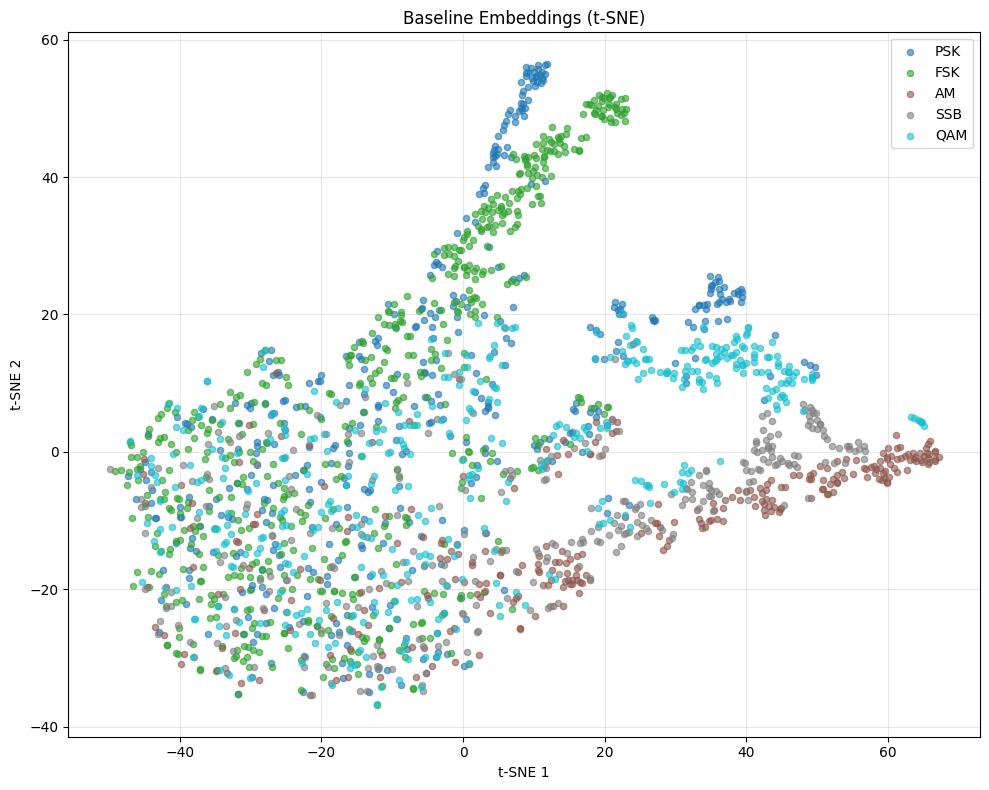

Computing t-SNE for 2000 samples...


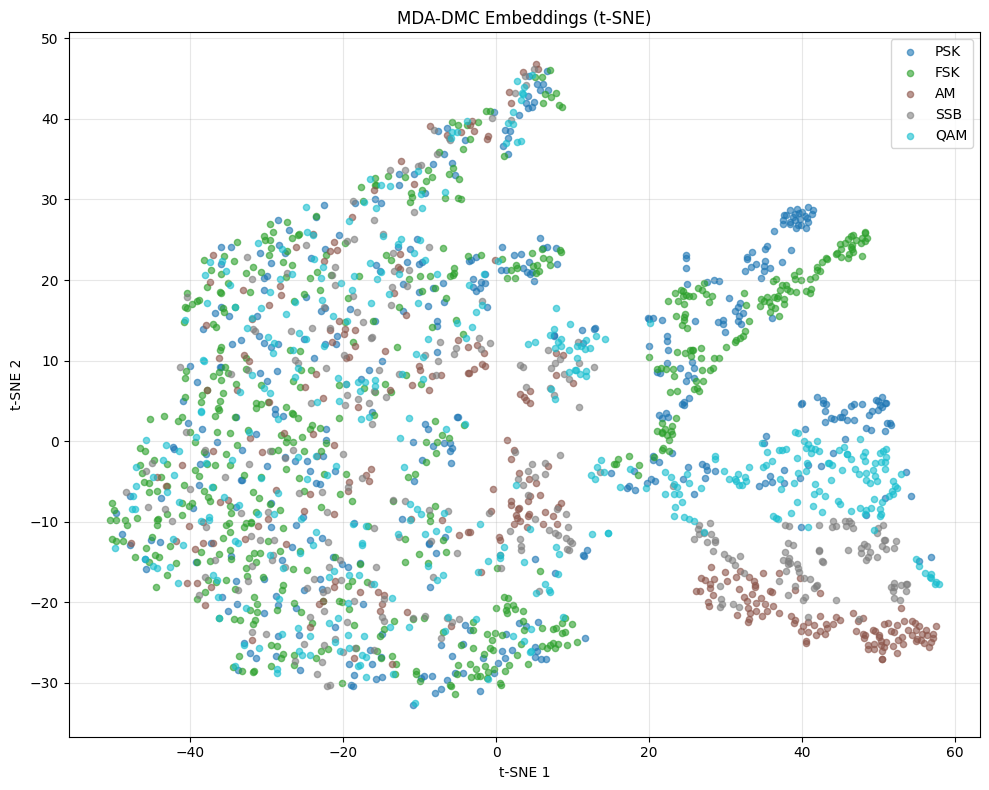

Computing t-SNE for 2000 samples...


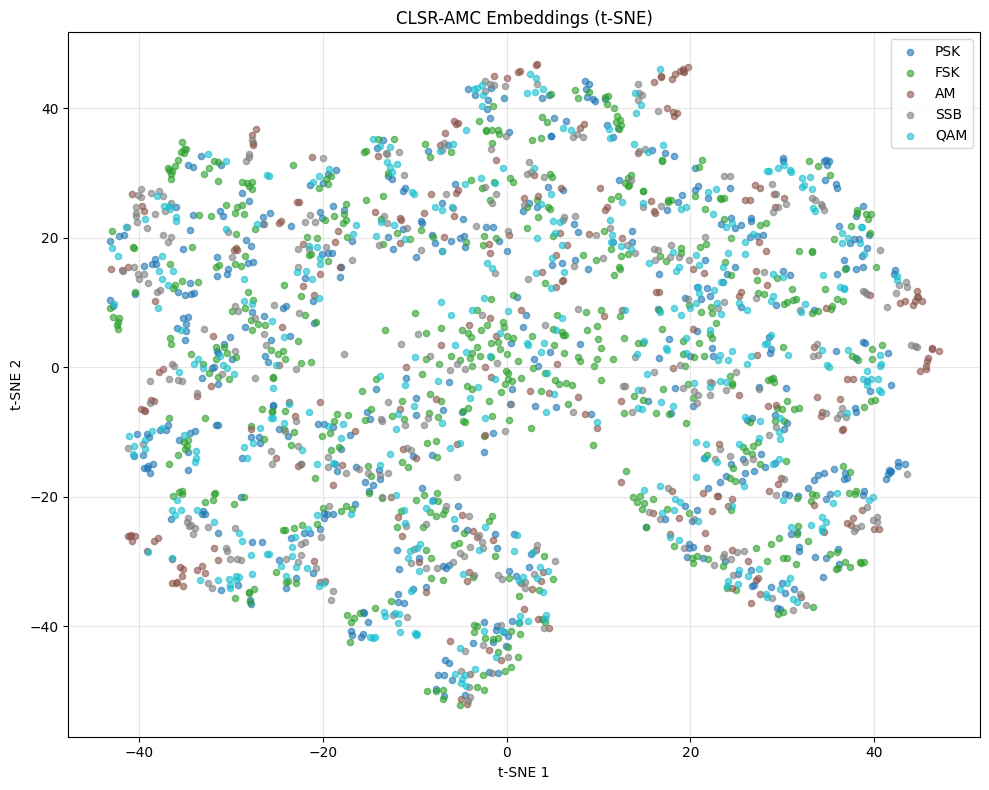

In [9]:
for name in models.keys():
    data = all_embeddings[name]
    fig = plot_tsne(
        data["embeddings"],
        data["labels"],
        family_names,
        title=f"{name} Embeddings (t-SNE)",
    )
    plt.tight_layout()
    plt.show()

## 5. SNR-Stratified Analysis


Baseline - Silhouette Score by SNR:
----------------------------------------
  SNR   0 to  10 dB: -0.0448 (n=1548)
  SNR  10 to  20 dB: 0.0138 (n=1517)


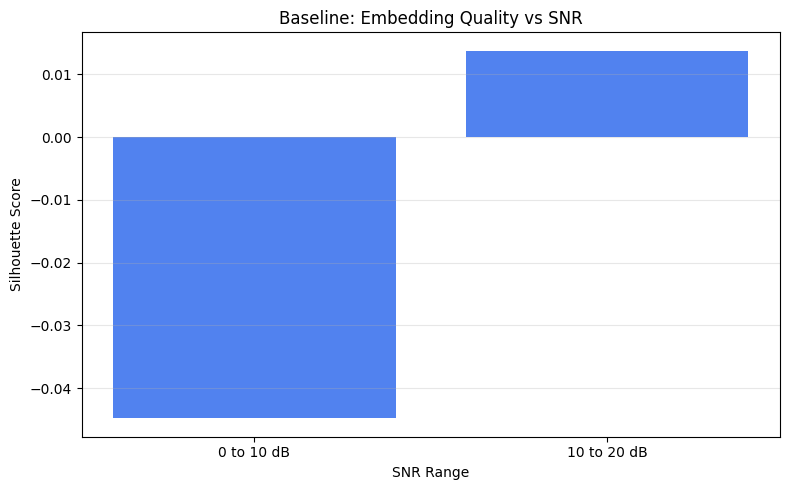

In [10]:
# Analyze embedding quality at different SNR levels
model_name = list(models.keys())[0] if models else None

if model_name:
    data = all_embeddings[model_name]
    embeddings = data["embeddings"]
    labels = data["labels"]
    snrs = data["snrs"]

    if snrs is not None:
        # Compute silhouette score for different SNR ranges
        snr_ranges = [(-10, 0), (0, 10), (10, 20)]

        print(f"\n{model_name} - Silhouette Score by SNR:")
        print("-" * 40)

        scores = []
        for low, high in snr_ranges:
            mask = (snrs >= low) & (snrs < high)
            if mask.sum() > 100 and len(np.unique(labels[mask])) > 1:
                score = silhouette_score(embeddings[mask], labels[mask])
                scores.append((f"{low} to {high} dB", score))
                print(f"  SNR {low:>3} to {high:>3} dB: {score:.4f} (n={mask.sum()})")

        # Plot
        fig, ax = plt.subplots(figsize=(8, 5))
        x = [s[0] for s in scores]
        y = [s[1] for s in scores]
        ax.bar(x, y, color="#2563eb", alpha=0.8)
        ax.set_ylabel("Silhouette Score")
        ax.set_xlabel("SNR Range")
        ax.set_title(f"{model_name}: Embedding Quality vs SNR")
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()

## 6. Inter/Intra Class Distance Analysis

In [11]:
def compute_class_distances(embeddings, labels):
    """Compute inter and intra class distances."""
    unique_labels = np.unique(labels)

    # Compute class centroids
    centroids = {}
    for label in unique_labels:
        mask = labels == label
        centroids[label] = embeddings[mask].mean(axis=0)

    # Intra-class: average distance from points to their centroid
    intra_distances = []
    for label in unique_labels:
        mask = labels == label
        dists = np.linalg.norm(embeddings[mask] - centroids[label], axis=1)
        intra_distances.append(dists.mean())
    avg_intra = np.mean(intra_distances)

    # Inter-class: average distance between centroids
    inter_distances = []
    for i, l1 in enumerate(unique_labels):
        for l2 in unique_labels[i + 1 :]:
            dist = np.linalg.norm(centroids[l1] - centroids[l2])
            inter_distances.append(dist)
    avg_inter = np.mean(inter_distances)

    return avg_inter, avg_intra, avg_inter / (avg_intra + 1e-8)

In [12]:
print("\nInter/Intra Class Distance Analysis:")
print("=" * 60)
print(f"{'Model':<15} {'Inter':>10} {'Intra':>10} {'Ratio':>10}")
print("-" * 60)

for name, data in all_embeddings.items():
    inter, intra, ratio = compute_class_distances(data["embeddings"], data["labels"])
    all_metrics[name]["inter_class"] = inter
    all_metrics[name]["intra_class"] = intra
    all_metrics[name]["inter_intra_ratio"] = ratio
    print(f"{name:<15} {inter:>10.4f} {intra:>10.4f} {ratio:>10.4f}")

print("\nInterpretation:")
print("  - Higher inter-class distance = better class separation")
print("  - Lower intra-class distance = more compact clusters")
print("  - Higher ratio = better overall embedding quality")


Inter/Intra Class Distance Analysis:
Model                Inter      Intra      Ratio
------------------------------------------------------------
Baseline            1.1415     1.6207     0.7043
MDA-DMC             1.1270     2.0198     0.5580
CLSR-AMC            0.9139     2.5235     0.3622

Interpretation:
  - Higher inter-class distance = better class separation
  - Lower intra-class distance = more compact clusters
  - Higher ratio = better overall embedding quality


## 7. Comparison Summary

In [13]:
if all_metrics:
    print("\nEmbedding Quality Summary:")
    print("=" * 50)
    print(f"{'Model':<15} {'Silhouette':>12} {'Inter/Intra':>12}")
    print("-" * 50)

    for name, metrics in all_metrics.items():
        sil = metrics.get("silhouette_score", 0)
        ratio = metrics.get("inter_intra_ratio", 0)
        print(f"{name:<15} {sil:>12.4f} {ratio:>12.4f}")

    # Find best model
    best_sil = max(all_metrics.items(), key=lambda x: x[1].get("silhouette_score", 0))
    best_ratio = max(all_metrics.items(), key=lambda x: x[1].get("inter_intra_ratio", 0))

    print(f"\nBest silhouette score: {best_sil[0]}")
    print(f"Best inter/intra ratio: {best_ratio[0]}")


Embedding Quality Summary:
Model             Silhouette  Inter/Intra
--------------------------------------------------
Baseline             -0.0526       0.7043
MDA-DMC              -0.0330       0.5580
CLSR-AMC             -0.0241       0.3622

Best silhouette score: CLSR-AMC
Best inter/intra ratio: Baseline
